In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import torch 
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import rasterio

In [4]:
#set paths 
base_dir = "/Users/sofiasuhinin/Desktop/Subglacial_Lakes_Data"
lake_location_path = os.path.join(base_dir, "lake_locations.csv")
lake_and_null_path = os.path.join(base_dir, "lake_and_null_loc.csv")
dataset_split_path = os.path.join(base_dir, "dataset_split.csv")
lake_masks = os.path.join(base_dir, "lake_masks")
training_set = os.path.join(base_dir, "lakesTS_2")

lake_location = pd.read_csv(lake_location_path)
lake_and_null = pd.read_csv(lake_and_null_path)
dataset_split = pd.read_csv(dataset_split_path)

In [ ]:
# list all netcdf files in each folder
tile_files = sorted([f for f in os.listdir(training_set) if f.endswith(".nc")])
mask_files = sorted([f for f in os.listdir(lake_masks) if f.endswith(".nc")])

print("number of training files:", len(tile_files))
print("number of lake mask files:", len(mask_files))
    # we expect a difference because there are some null training files - i.e., where there are not lakes = no lake masks

print(tile_files[:10])
print(mask_files[:10])

number of training files: 105
number of lake mask files: 85
['ANZAC19.nc', 'Academy45.nc', 'Academy91.nc', 'Adams17.nc', 'Adams19.nc', 'Amery22.nc', 'Beardmore107.nc', 'Beardmore18.nc', 'Beardmore66.nc', 'Beaver27.nc']
['ANZAC19_mask.nc', 'Academy45_mask.nc', 'Academy91_mask.nc', 'Adams17_mask.nc', 'Adams19_mask.nc', 'Amery22_mask.nc', 'Beardmore107_mask.nc', 'Beardmore18_mask.nc', 'Beardmore66_mask.nc', 'Beaver27_mask.nc']


In [9]:
rows = []

for tile in tile_files:
    
    name = tile.replace(".nc", "")
    
    tile_path = os.path.join(training_set, tile)
    
    mask_file = f"{name}_mask.nc"
    mask_path = os.path.join(lake_masks, mask_file)
    
    if os.path.exists(mask_path):
        has_mask = True
    else:
        mask_path = None
        has_mask = False
    
    rows.append({
        "name": name,
        "tile_path": tile_path,
        "mask_path": mask_path,
        "has_lake": int(has_mask)
    })

dataset_df = pd.DataFrame(rows)

print(dataset_df.head())
print()

        name                                          tile_path  \
0    ANZAC19  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   
1  Academy45  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   
2  Academy91  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   
3    Adams17  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   
4    Adams19  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   

                                           mask_path  has_lake  
0  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1  
1  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1  
2  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1  
3  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1  
4  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1  



In [13]:
dataset_split["file_name"] = (
    dataset_split["file"]
    .astype(str)
    .str.strip()
    .str.replace("\\", "/", regex=False)
    .str.split("/")
    .str[-1]
)

dataset_split["name"] = dataset_split["file_name"].str.replace(".nc", "", regex=False)

print(dataset_split[["file", "file_name", "name", "dataset"]].head())

                                                file       file_name  \
0  /Users/Ashley Howard/ESS569/MLGEO2026_Subglaci...       null_8.nc   
1  /Users/Ashley Howard/ESS569/MLGEO2026_Subglaci...      Totten7.nc   
2  /Users/Ashley Howard/ESS569/MLGEO2026_Subglaci...  Institute14.nc   
3  /Users/Ashley Howard/ESS569/MLGEO2026_Subglaci...     Totten82.nc   
4  /Users/Ashley Howard/ESS569/MLGEO2026_Subglaci...      Amery22.nc   

          name dataset  
0       null_8   train  
1      Totten7   train  
2  Institute14   train  
3     Totten82   train  
4      Amery22   train  


In [14]:
# prepare split table

dataset_split["name"] = dataset_split["file_name"].str.replace(".nc", "", regex=False)

# merge split with dataset dataframe
dataset_df = dataset_df.merge(
    dataset_split[["name", "dataset"]],
    on="name",
    how="left"
)

print(dataset_df.head())
print()
print(dataset_df["dataset"].value_counts())

        name                                          tile_path  \
0    ANZAC19  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   
1  Academy45  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   
2  Academy91  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   
3    Adams17  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   
4    Adams19  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...   

                                           mask_path  has_lake dataset  
0  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1    test  
1  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1   train  
2  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1   train  
3  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1   train  
4  /Users/sofiasuhinin/Desktop/Subglacial_Lakes_D...         1    test  

dataset
train    73
test     16
val      16
Name: count, dtype: int64


In [ ]:
train_df = dataset_df[dataset_df["dataset"] == "train"].reset_index(drop=True)
val_df = dataset_df[dataset_df["dataset"] == "val"].reset_index(drop=True)
test_df = dataset_df[dataset_df["dataset"] == "test"].reset_index(drop=True)

#confirm
print("train:", len(train_df))
print("validation:", len(val_df))
print("test:", len(test_df))

Train: 73
Validation: 16
Test: 16


In [17]:

class LakeSegmentationDataset(Dataset):
    def __init__(self, dataframe, tile_var="anomaly", mask_var="lake_mask"):
        self.df = dataframe.reset_index(drop=True)
        self.tile_var = tile_var
        self.mask_var = mask_var

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # load tile
        tile_ds = xr.open_dataset(row["tile_path"])
        arr = tile_ds[self.tile_var].values.astype(np.float32)   # (time, y, x)
        tile_ds.close()

        # collapse time into 2 channels: mean and std
        valid = np.isfinite(arr)
        valid_count = valid.sum(axis=0)

        arr_zeroed = np.where(valid, arr, 0.0)
        mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)

        diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
        std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))

        mean_img[valid_count == 0] = 0.0
        std_img[valid_count == 0] = 0.0

        x = np.stack([mean_img, std_img], axis=0)   # (2, H, W)

        # normalize channels
        for c in range(x.shape[0]):
            mu = x[c].mean()
            sigma = x[c].std()
            if sigma < 1e-6:
                x[c] = x[c] - mu
            else:
                x[c] = (x[c] - mu) / sigma

        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        # load mask
        if pd.isna(row["mask_path"]) or row["mask_path"] is None:
            mask = np.zeros((x.shape[1], x.shape[2]), dtype=np.float32)
        else:
            mask_ds = xr.open_dataset(row["mask_path"])
            mask = mask_ds[self.mask_var].values.astype(np.float32)   # (y, x)
            mask_ds.close()

        # force binary
        mask = (mask > 0).astype(np.float32)

        # add channel dim
        mask = np.expand_dims(mask, axis=0)   # (1, H, W)

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32)
        )

In [18]:
train_dataset = LakeSegmentationDataset(train_df, tile_var="anomaly", mask_var="lake_mask")
val_dataset = LakeSegmentationDataset(val_df, tile_var="anomaly", mask_var="lake_mask")
test_dataset = LakeSegmentationDataset(test_df, tile_var="anomaly", mask_var="lake_mask")

In [19]:
X, y = train_dataset[0]

print("Input shape:", X.shape)
print("Mask shape:", y.shape)
print("Mask unique values:", torch.unique(y))

Input shape: torch.Size([2, 501, 501])
Mask shape: torch.Size([1, 501, 501])
Mask unique values: tensor([0., 1.])


In [20]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [21]:
X_batch, y_batch = next(iter(train_loader))

print("Batch input shape:", X_batch.shape)
print("Batch mask shape:", y_batch.shape)

Batch input shape: torch.Size([1, 2, 501, 501])
Batch mask shape: torch.Size([1, 1, 501, 501])


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):

    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = conv_block(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = conv_block(64, 32)

        self.final = nn.Conv2d(32, out_channels, 1)

    def _match_size(self, src, target):
        """
        Resize src spatial dims to match target spatial dims.
        src: tensor to resize
        target: tensor whose H,W we want
        """
        if src.shape[-2:] != target.shape[-2:]:
            src = F.interpolate(src, size=target.shape[-2:], mode="bilinear", align_corners=False)
        return src

    def forward(self, x):
        e1 = self.enc1(x)                  # [B, 32, 501, 501]
        e2 = self.enc2(self.pool1(e1))     # [B, 64, 250, 250]
        e3 = self.enc3(self.pool2(e2))     # [B, 128, 125, 125]

        b = self.bottleneck(self.pool3(e3))  # [B, 256, 62, 62]

        d3 = self.up3(b)                   # may be [B, 128, 124, 124]
        d3 = self._match_size(d3, e3)      # force to [B, 128, 125, 125]
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = self._match_size(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self._match_size(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = self._match_size(out, x)   # just to be safe
        return out

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=2, out_channels=1).to(device)

print(device)
print(model)

cpu
UNet(
  (enc1): Sequential(
    (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

In [30]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [31]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(X)              # [B, 1, H, W]
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)

    return total_loss / len(loader.dataset)

In [32]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        total_loss += loss.item() * X.size(0)

    return total_loss / len(loader.dataset)

In [33]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 0.4286 | Val Loss: 0.1410
Epoch 2/10 | Train Loss: 0.1340 | Val Loss: 0.1230
Epoch 3/10 | Train Loss: 0.1252 | Val Loss: 0.1288
Epoch 4/10 | Train Loss: 0.1130 | Val Loss: 0.0987
Epoch 5/10 | Train Loss: 0.1022 | Val Loss: 0.0973
Epoch 6/10 | Train Loss: 0.0968 | Val Loss: 0.0858
Epoch 7/10 | Train Loss: 0.0919 | Val Loss: 0.0830
Epoch 8/10 | Train Loss: 0.0917 | Val Loss: 0.0882
Epoch 9/10 | Train Loss: 0.0894 | Val Loss: 0.0808
Epoch 10/10 | Train Loss: 0.0974 | Val Loss: 0.0806


In [34]:
import torch

def dice_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()


def iou_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    total = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    union = total - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

In [35]:
@torch.no_grad()
def evaluate_segmentation(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_batches = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_dice += dice_score_from_logits(logits, y)
        total_iou += iou_score_from_logits(logits, y)
        n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "dice": total_dice / n_batches,
        "iou": total_iou / n_batches,
    }

In [37]:
val_metrics = evaluate_segmentation(model, val_loader, criterion, device)
test_metrics = evaluate_segmentation(model, test_loader, criterion, device)

print("Validation Metrics:")
print(val_metrics)

print("\nTest Metrics:")
print(test_metrics)

Validation Metrics:
{'loss': 0.08059452843735926, 'dice': 0.12500000026907881, 'iou': 0.12500000026907881}

Test Metrics:
{'loss': 0.11857100035558688, 'dice': 0.2500000002160643, 'iou': 0.2500000002160643}


In [38]:
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_prediction(model, dataset, idx, device, threshold=0.5):
    model.eval()

    X, y = dataset[idx]
    X_in = X.unsqueeze(0).to(device)

    logits = model(X_in)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred = (probs > threshold).astype(float)

    X_np = X.cpu().numpy()
    y_np = y.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(X_np[0], cmap="coolwarm")
    axes[0].set_title("Input: Mean anomaly")
    axes[0].axis("off")

    axes[1].imshow(X_np[1], cmap="viridis")
    axes[1].set_title("Input: Std anomaly")
    axes[1].axis("off")

    axes[2].imshow(y_np, cmap="gray")
    axes[2].set_title("True mask")
    axes[2].axis("off")

    axes[3].imshow(pred, cmap="gray")
    axes[3].set_title("Predicted mask")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

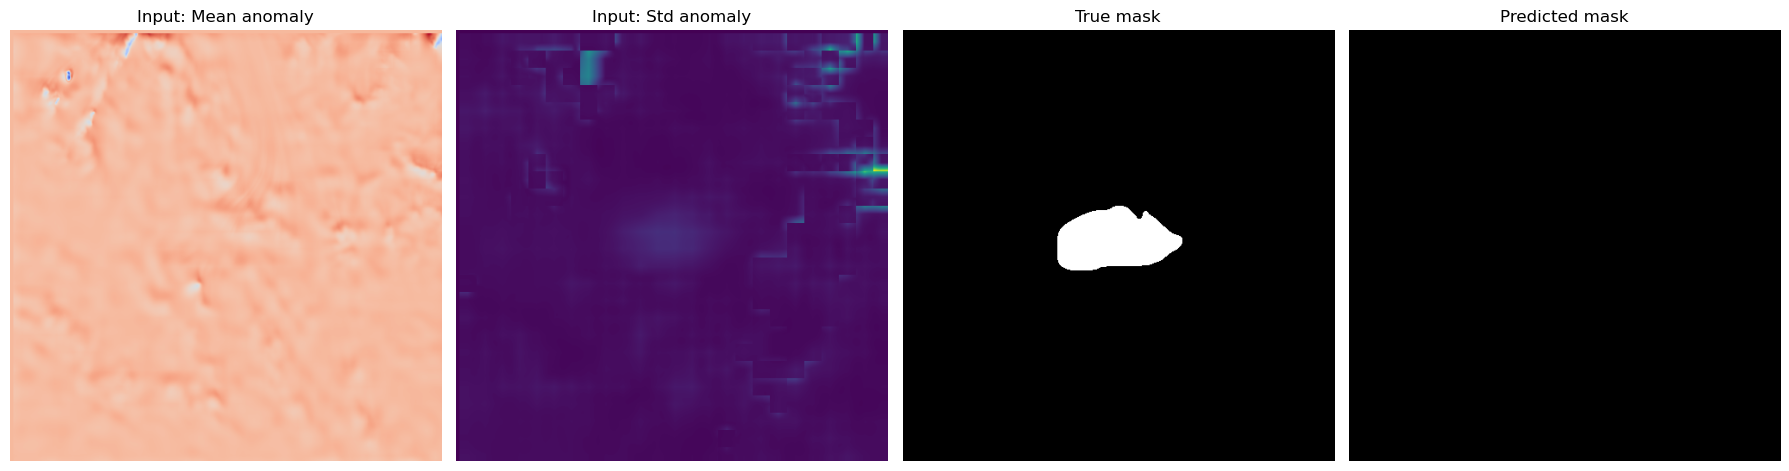

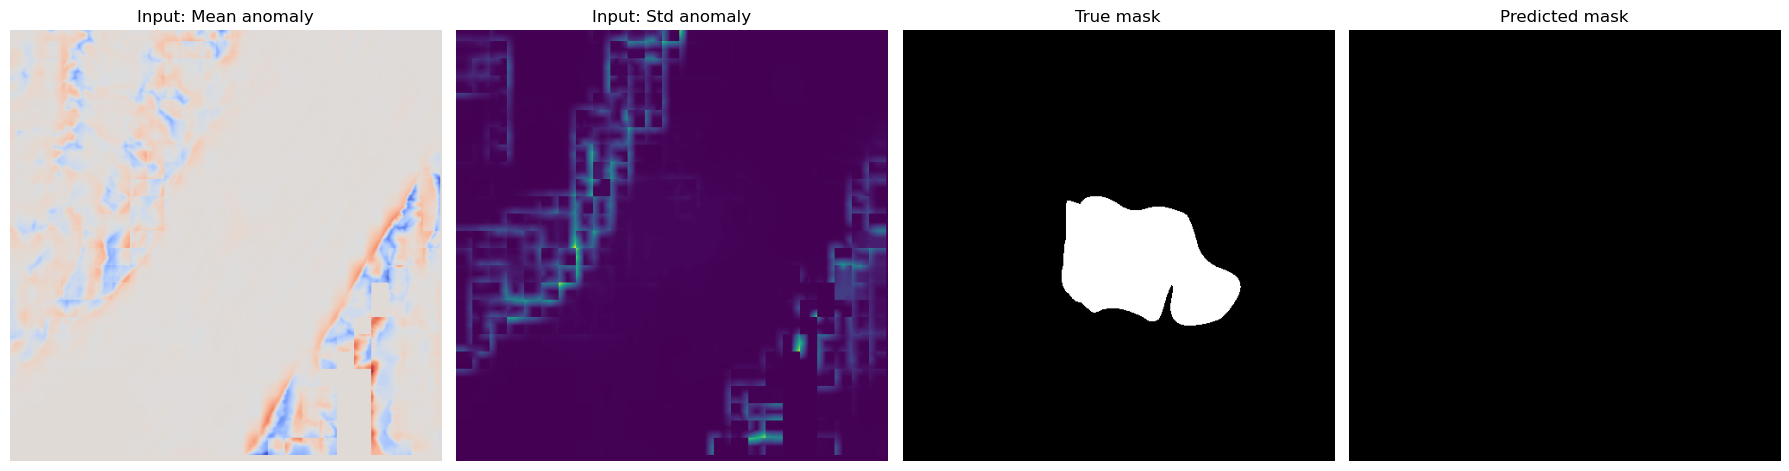

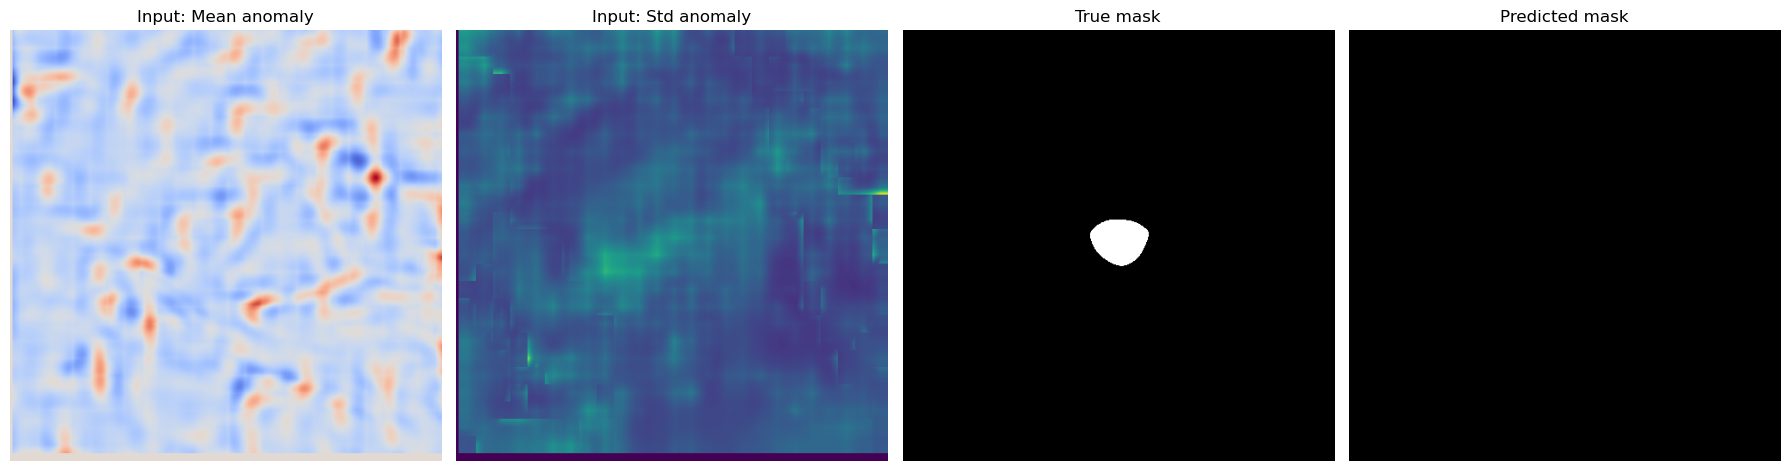

In [40]:
plot_prediction(model, val_dataset, 0, device)
plot_prediction(model, val_dataset, 1, device)
plot_prediction(model, val_dataset, 2, device)